In [4]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Importar el separador de muestras para entrenamiento y pruebas
from sklearn.model_selection import train_test_split

In [5]:
# Cargar conjunto de datos
datos = sns.load_dataset('iris')
datos

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [6]:
datos.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
datos['species'].size

150

In [8]:
datos.groupby('species').size()

species
setosa        50
versicolor    50
virginica     50
dtype: int64

In [9]:
# Seleccionar datos de prueba y entrenamiento
train, test = train_test_split(datos, test_size=0.4, stratify=datos['species'], random_state=42)

In [10]:
train['species'].value_counts()

species
virginica     30
setosa        30
versicolor    30
Name: count, dtype: int64

## Inspección visual

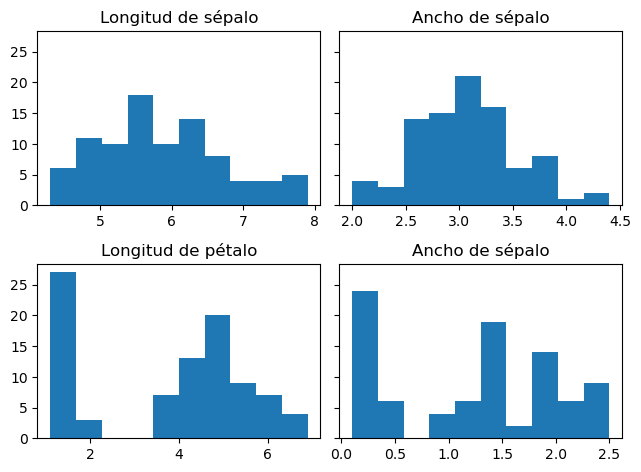

In [11]:
# Generación de histogramas
n_bins = 10
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2,ncols=2, sharey=True)
ax1.hist(train['sepal_length'], bins=n_bins)
ax1.set_title('Longitud de sépalo')

ax2.hist(train['sepal_width'], bins=n_bins)
ax2.set_title('Ancho de sépalo')

ax3.hist(train['petal_length'], bins=n_bins)
ax3.set_title('Longitud de pétalo')

ax4.hist(train['petal_width'], bins=n_bins)
ax4.set_title('Ancho de sépalo')

fig.tight_layout(pad=1.0)

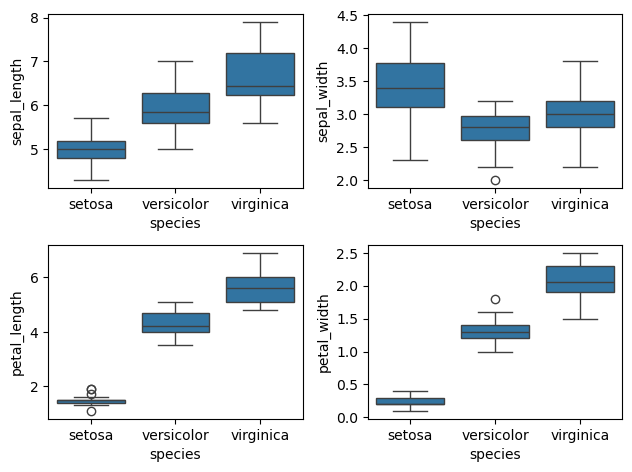

In [12]:
# Diagrama Box-plot
fig1, axs1 = plt.subplots(2,2)
fn = ['sepal_length', 'sepal_width','petal_length','petal_width']
cn = ['setosa','versicolor','virginica']

sns.boxplot(x='species',y=fn[0],data=train,order=cn,ax=axs1[0,0])
sns.boxplot(x='species',y=fn[1],data=train,order=cn,ax=axs1[0,1])
sns.boxplot(x='species',y=fn[2],data=train,order=cn,ax=axs1[1,0])
sns.boxplot(x='species',y=fn[3],data=train,order=cn,ax=axs1[1,1])

fig1.tight_layout(pad=1.0);

In [13]:
sns.set_palette("Set2")

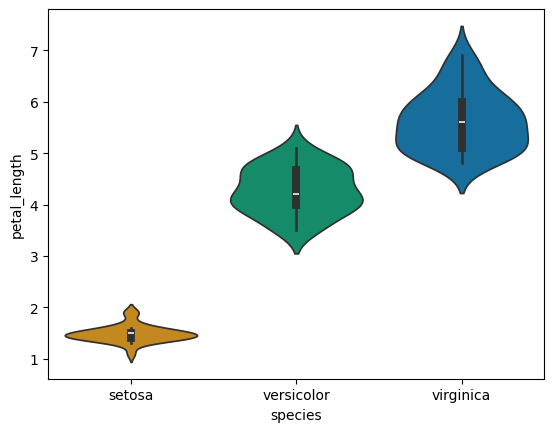

In [14]:
sns.violinplot(x='species', y ='petal_length', data=train, hue='species', order=cn, palette='colorblind');

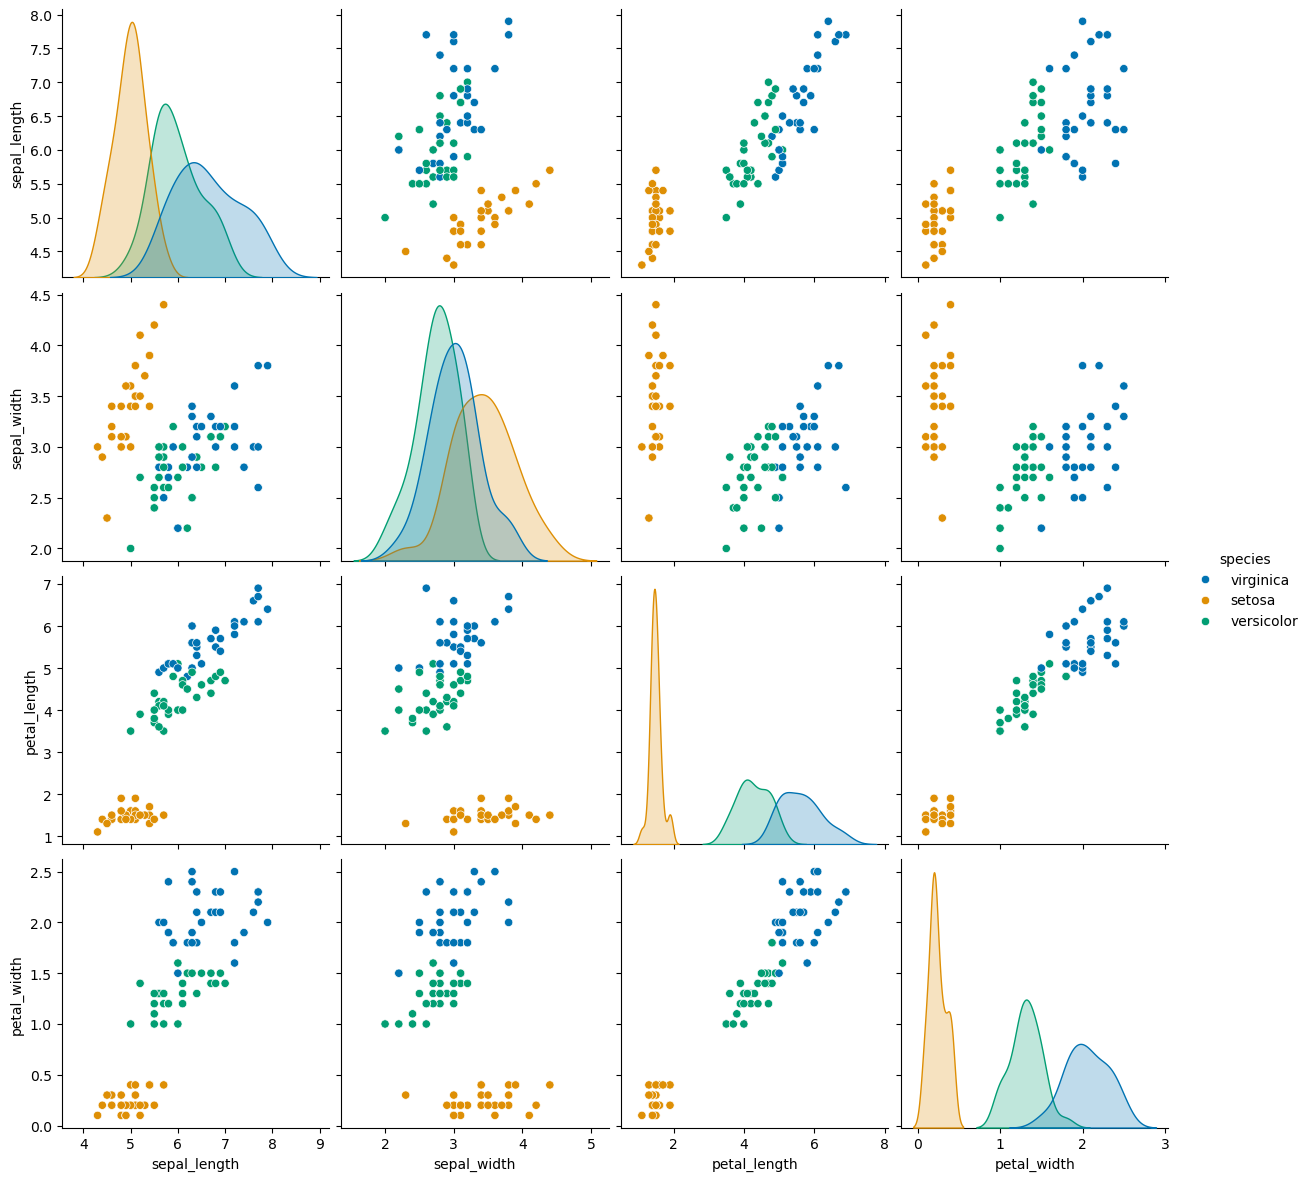

In [15]:
# Diagrama de dispersión de atributos emparejados
sns.pairplot(data=train, hue='species', height=3, palette='colorblind');

In [16]:
# Matriz de correlación
corrmat = train.corr(numeric_only=True)
corrmat

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.066927,0.880222,0.820610
sepal_width,-0.066927,1.000000,-0.369708,-0.324162
petal_length,0.880222,-0.369708,1.000000,0.967165
petal_width,0.820610,-0.324162,0.967165,1.000000


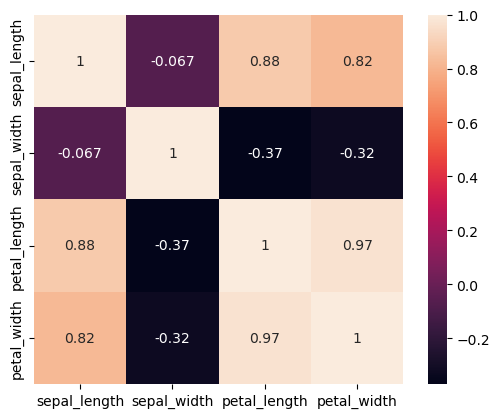

In [17]:
# Mapa de calor
sns.set_palette('husl',8)
sns.heatmap(corrmat, annot=True, square=True);

In [18]:
from pandas.plotting import parallel_coordinates

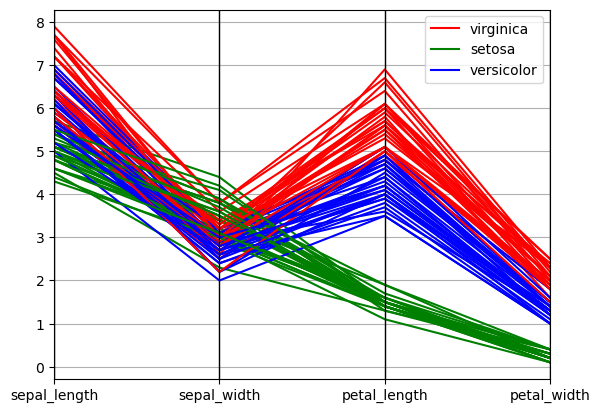

In [19]:
parallel_coordinates(train, 'species', color=['red', 'green', 'blue']);